# Paquetes

In [1]:
from sklearn.metrics import roc_auc_score, f1_score, accuracy_score, roc_curve
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import pickle

from tensorflow.keras.regularizers import l2
from sklearn.model_selection import KFold
from tensorflow.keras.callbacks import ReduceLROnPlateau, ModelCheckpoint, EarlyStopping
import numpy as np

import pennylane as qml
from pennylane import numpy as np

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.optimizers import Adam
import os
from PIL import Image
from multiprocessing import Pool
import pickle

import matplotlib.pyplot as plt
import matplotlib.lines as mlines

import pandas as pd

from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split

from collections import defaultdict

import re

import random

In [2]:
random_seed=42


# Carga de Datos

### Recuento inicial

In [3]:
base_dirs = ["ACDC", "LaFe"]
categories = ["C", "MCD", "MCA", "MU"]

counts = {base: defaultdict(int) for base in base_dirs}
total_counts = defaultdict(int)

for base_dir in base_dirs:
    for subfolder in categories:
        path = "dataset/" + base_dir + "/" + subfolder
        if os.path.exists(path):
            patients = {f for f in os.listdir(path) if f.endswith(".nii.gz")}
            counts[base_dir][subfolder] = len(patients)
            total_counts[subfolder] += len(patients)

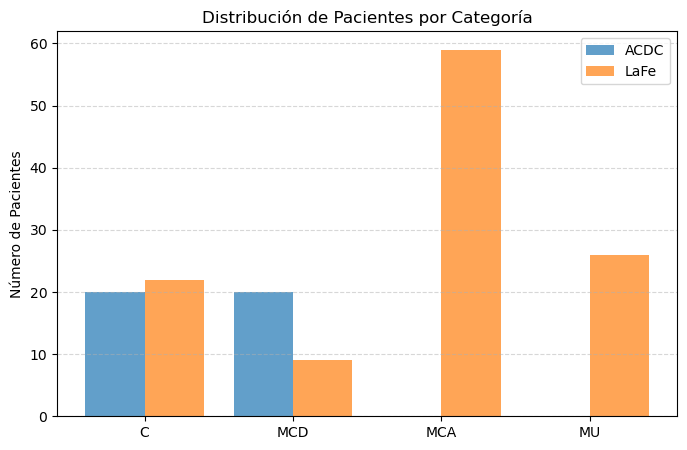

In [4]:
fig, ax = plt.subplots(figsize=(8, 5))
x = range(len(categories))

width = 0.4
ax.bar(x, [counts["ACDC"][cat] for cat in categories], width=width, label="ACDC", alpha=0.7)
ax.bar([i + width for i in x], [counts["LaFe"][cat] for cat in categories], width=width, label="LaFe", alpha=0.7)

ax.set_xticks([i + width / 2 for i in x])
ax.set_xticklabels(categories)
ax.set_ylabel("Número de Pacientes")
ax.set_title("Distribución de Pacientes por Categoría")
ax.legend()
plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.show()

In [5]:
df_count = pd.DataFrame(counts).T 
df_count = pd.DataFrame(counts).T.fillna(0).astype(int)
df_count["Total"] = df_count.sum(axis=1)
df_count.loc["Total"] = df_count.sum(axis=0)

df_count

,C,MCD,MCA,MU,Total
ACDC,20,20,0,0,40
LaFe,22,9,59,26,116
Total,42,29,59,26,156


### Muestreo uniforme

Priorizamos los pacientes de La Fe, usando los del challenge en caso de ausencia de datos

In [4]:
base_dir = "LaFe"
num_samples = 35

random.seed(random_seed)

data = {category: [] for category in categories}

for subfolder in categories:
    path = "dataset/" + base_dir + "/" + subfolder
    if os.path.exists(path):
        patients = {f for f in os.listdir(path) if f.endswith(".nii.gz")}
        sampled_patients = random.sample(patients, min(num_samples, len(patients)))
        data[subfolder].extend([base_dir+"/"+subfolder+"/"+patient.replace(".nii.gz", "") for patient in sampled_patients])

base_dir = "ACDC"
for subfolder in categories:
    path = "dataset/" + base_dir + "/" + subfolder
    if os.path.exists(path):
        patients = {f for f in os.listdir(path) if f.endswith(".nii.gz")}
        sampled_patients = random.sample(patients, min(num_samples-len(data[subfolder]), len(patients)))
        data[subfolder].extend([base_dir+"/"+subfolder+"/"+patient.replace(".nii.gz", "") for patient in sampled_patients])

C:\Users\mateo\AppData\Local\Temp\ipykernel_23476\274377643.py:12: DeprecationWarning: Sampling from a set deprecated
since Python 3.9 and will be removed in a subsequent version.
  sampled_patients = random.sample(patients, min(num_samples, len(patients)))
C:\Users\mateo\AppData\Local\Temp\ipykernel_23476\274377643.py:20: DeprecationWarning: Sampling from a set deprecated
since Python 3.9 and will be removed in a subsequent version.
  sampled_patients = random.sample(patients, min(num_samples-len(data[subfolder]), len(patients)))


In [5]:
all_data = [(p, cat) for cat, patients in data.items() for p in patients]

df = pd.DataFrame(all_data, columns=["patient", "category"])

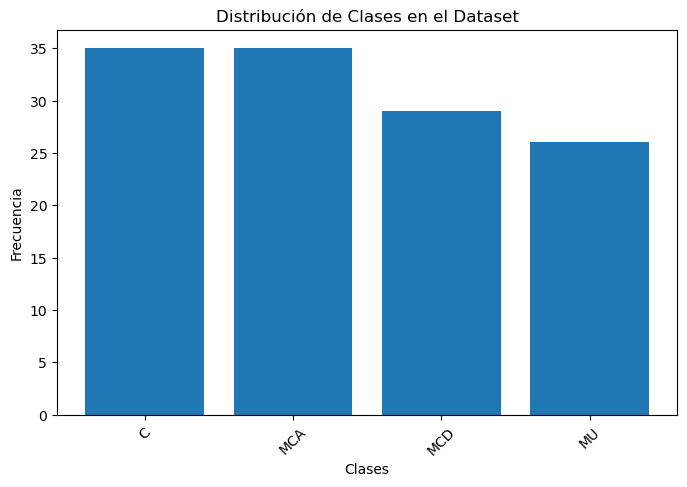

In [6]:
class_counts = df["category"].value_counts()

# Graficar el histograma
plt.figure(figsize=(8, 5))
plt.bar(class_counts.index, class_counts.values)

# Personalizar el gráfico
plt.xlabel("Clases")
plt.ylabel("Frecuencia")
plt.title("Distribución de Clases en el Dataset")
plt.xticks(rotation=45)

# Mostrar el histograma
plt.show()

## Partición

In [ ]:
train, temp = train_test_split(df, test_size=0.3, stratify=df["category"], random_state=42)
val, test = train_test_split(temp, test_size=1/3, stratify=temp["category"], random_state=42)

In [8]:
train

,patient,category
27,ACDC/C/patient062_4d_ES9,C
16,LaFe/C/C_10,C
109,LaFe/MU/9066,MU
100,LaFe/MU/MU_05,MU
57,ACDC/MCD/patient008_4d_ES13,MCD
...,...,...
24,ACDC/C/patient077_4d_ES9,C
113,LaFe/MU/9065,MU
65,LaFe/MCA/9108,MCA
47,ACDC/MCD/patient003_4d_ES15,MCD


# Crear datos (NO EJECUTAR)

## Train

In [3]:
extract_dir = "results/imagenes"

array_shape = (64, 64)

In [11]:
image_labels_tr = []
image_tr=[]

for _, row in train.iterrows():
    folder_path = row["patient"]
    category = row["category"]
    patient_name = os.path.basename(folder_path).split("/")[-1]
    path = extract_dir+"/"+folder_path
    for type in os.listdir(path):
        path = extract_dir+"/"+folder_path+"/"+type
        for img_path in os.listdir(path):
            path = extract_dir+"/"+folder_path+"/"+type+"/"+img_path
            img = Image.open(path)
            img = img.convert('RGB')
            img = img.resize(array_shape)
            img_array = np.array(img)

            img_number = re.search(r"_(\d{2})_", img_path).group(1)

            image_labels_tr.append({
                "patient_name": patient_name,
                "class": category,
                "image_type": type,
                "img_number": img_number,
            })

            image_tr.append(img_array)

image_tr = np.array(image_tr)

train_imgs_tf = (image_tr / 255)*np.pi
df_tr = pd.DataFrame(image_labels_tr)

print(df_tr.head(10))
print(df_tr.shape)

print(train_imgs_tf.shape)

with open("data_pi/train_imgs_tf1.pkl", "wb") as file:
    pickle.dump(train_imgs_tf, file)

with open("data_pi/df_tr1.pkl", "wb") as file:
    pickle.dump(df_tr, file)

        patient_name class       image_type img_number
0  patient062_4d_ES9     C  circunferencial         00
1  patient062_4d_ES9     C  circunferencial         01
2  patient062_4d_ES9     C  circunferencial         02
3  patient062_4d_ES9     C  circunferencial         03
4  patient062_4d_ES9     C  circunferencial         04
5  patient062_4d_ES9     C  circunferencial         05
6  patient062_4d_ES9     C  circunferencial         06
7  patient062_4d_ES9     C  circunferencial         07
8  patient062_4d_ES9     C  circunferencial         08
9  patient062_4d_ES9     C  circunferencial         09
(2784, 4)
(2784, 64, 64, 3)


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


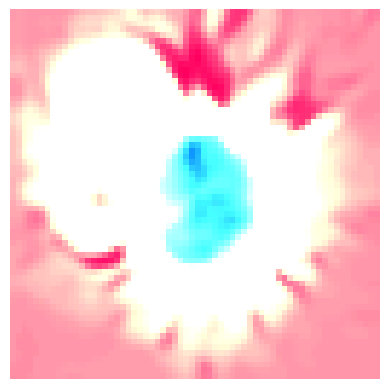

In [16]:
plt.imshow(train_imgs_tf[0,:,:])
plt.axis('off')
plt.show()

## Validation

In [17]:
image_labels_val = []
image_val=[]

for _, row in val.iterrows():
    folder_path = row["patient"]
    category = row["category"]
    patient_name = os.path.basename(folder_path).split("/")[-1]
    path = extract_dir+"/"+folder_path
    for type in os.listdir(path):
        path = extract_dir+"/"+folder_path+"/"+type
        for img_path in os.listdir(path):
            path = extract_dir+"/"+folder_path+"/"+type+"/"+img_path
            with Image.open(path) as img:
                img = img.convert('RGB')
                img = img.resize(array_shape)
                img_array = np.array(img)

            img_number = re.search(r"_(\d{2})_", img_path).group(1)

            image_labels_val.append({
                "patient_name": patient_name,
                "class": category,
                "image_type": type,
                "img_number": img_number,
            })

            image_val.append(img_array)

image_val = np.array(image_val)

val_imgs_tf = (image_val / 255)*np.pi
df_val = pd.DataFrame(image_labels_val)

print(df_val.head(10))
print(df_val.shape)

print(val_imgs_tf.shape)

with open("data_pi/val_imgs_tf1.pkl", "wb") as file:
    pickle.dump(val_imgs_tf, file)

with open("data_pi/df_val1.pkl", "wb") as file:
    pickle.dump(df_val, file)

        patient_name class       image_type img_number
0  patient075_4d_ES6     C  circunferencial         00
1  patient075_4d_ES6     C  circunferencial         01
2  patient075_4d_ES6     C  circunferencial         02
3  patient075_4d_ES6     C  circunferencial         03
4  patient075_4d_ES6     C  circunferencial         04
5  patient075_4d_ES6     C  circunferencial         05
6  patient075_4d_ES6     C  circunferencial         06
7  patient075_4d_ES6     C  circunferencial         07
8  patient075_4d_ES6     C  circunferencial         08
9  patient075_4d_ES6     C  circunferencial         09
(800, 4)
(800, 64, 64, 3)


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


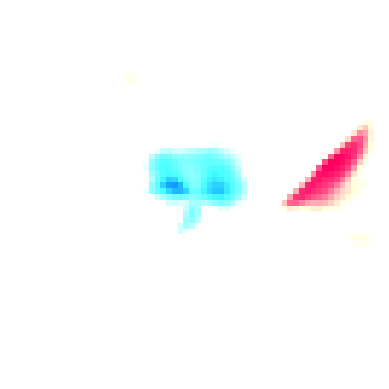

In [18]:
plt.imshow(val_imgs_tf[0,:,:])
plt.axis('off')
plt.show()

## Test

In [19]:
image_labels_test = []
image_test=[]

for _, row in test.iterrows():
    folder_path = row["patient"]
    category = row["category"]
    patient_name = os.path.basename(folder_path).split("/")[-1]
    path = extract_dir+"/"+folder_path
    for type in os.listdir(path):
        path = extract_dir+"/"+folder_path+"/"+type
        for img_path in os.listdir(path):
            path = extract_dir+"/"+folder_path+"/"+type+"/"+img_path
            with Image.open(path) as img:
                img = img.convert('RGB')
                img = img.resize(array_shape)
                img_array = np.array(img)

            img_number = re.search(r"_(\d{2})_", img_path).group(1)

            image_labels_test.append({
                "patient_name": patient_name,
                "class": category,
                "image_type": type,
                "img_number": img_number,
            })

            image_test.append(img_array)

image_test = np.array(image_test)

test_imgs_tf = (image_test / 255) *np.pi
df_test = pd.DataFrame(image_labels_test)

print(df_test.head(10))
print(df_test.shape)

print(test_imgs_tf.shape)

with open("data_pi/test_imgs_tf1.pkl", "wb") as file:
    pickle.dump(test_imgs_tf, file)

with open("data_pi/df_test1.pkl", "wb") as file:
    pickle.dump(df_test, file)

         patient_name class       image_type img_number
0  patient020_4d_ES11   MCD  circunferencial         00
1  patient020_4d_ES11   MCD  circunferencial         01
2  patient020_4d_ES11   MCD  circunferencial         02
3  patient020_4d_ES11   MCD  circunferencial         03
4  patient020_4d_ES11   MCD  circunferencial         04
5  patient020_4d_ES11   MCD  circunferencial         05
6  patient020_4d_ES11   MCD  circunferencial         06
7  patient020_4d_ES11   MCD  circunferencial         07
8  patient020_4d_ES11   MCD  circunferencial         08
9  patient020_4d_ES11   MCD  circunferencial         09
(416, 4)
(416, 64, 64, 3)


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


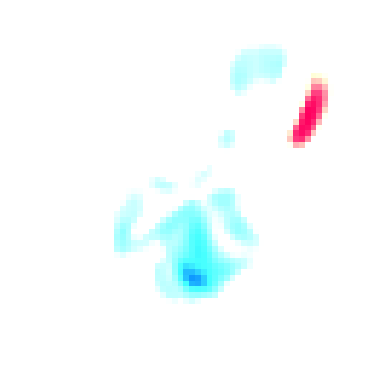

In [20]:
plt.imshow(test_imgs_tf[0,:,:])
plt.axis('off')
plt.show()

## Estadísticas de los datos

In [52]:
def plot_class_distribution(labels, dataset_name):
    unique_classes, counts = np.unique(labels, return_counts=True)
    plt.bar(unique_classes, counts)
    plt.title(f'Class Distribution in {dataset_name} Set')
    plt.xlabel('Class')
    plt.ylabel('Count')
    plt.show()


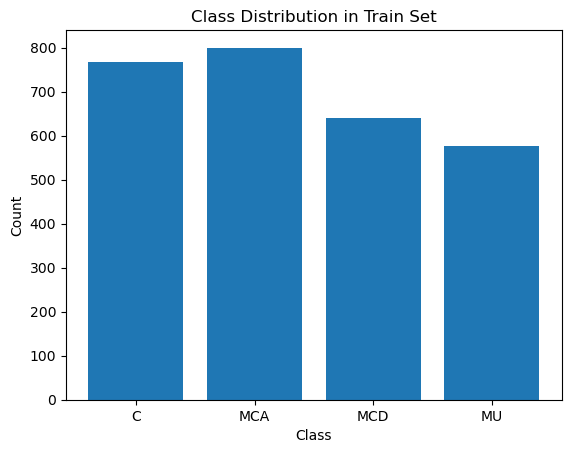

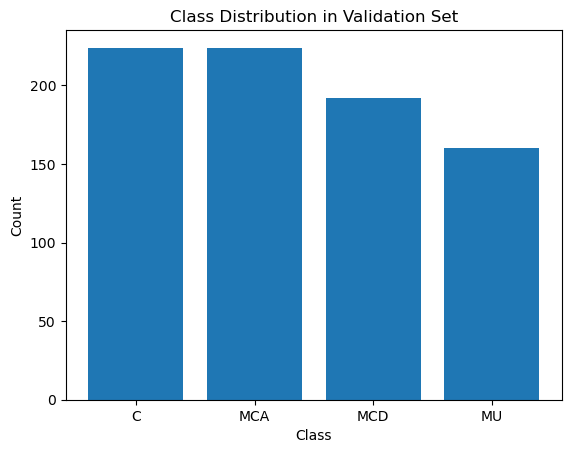

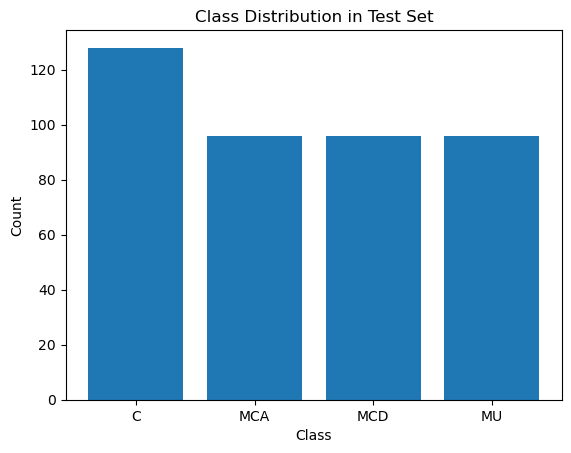

In [53]:
plot_class_distribution(df_tr["class"], 'Train')
plot_class_distribution(df_val["class"], 'Validation')
plot_class_distribution(df_test["class"], 'Test')

# Carga de datos

In [3]:
with open("data/nopi/train_imgs_tf.pkl", "rb") as f:
    train_imgs_tf = pickle.load(f)
with open("data/nopi/df_tr.pkl", "rb") as f:
    df_tr = pickle.load(f)

df_tr_rad = df_tr[df_tr["image_type"] == "radial"]
df_tr_circ = df_tr[df_tr["image_type"] == "circunferencial"]

train_imgs_tf_rad = train_imgs_tf[df_tr_rad.index]
train_imgs_tf_circ = train_imgs_tf[df_tr_circ.index]

with open("data/nopi/val_imgs_tf.pkl", "rb") as f:
    val_imgs_tf = pickle.load(f)
with open("data/nopi/df_val.pkl", "rb") as f:
    df_val = pickle.load(f)   

df_val_rad = df_val[df_val["image_type"] == "radial"]
df_val_circ = df_val[df_val["image_type"] == "circunferencial"]

val_imgs_tf_rad = val_imgs_tf[df_val_rad.index]
val_imgs_tf_circ = val_imgs_tf[df_val_circ.index]

with open("data/nopi/test_imgs_tf.pkl", "rb") as f:
    test_imgs_tf = pickle.load(f)
with open("data/nopi/df_test.pkl", "rb") as f:
    df_test = pickle.load(f)

df_test_rad = df_test[df_test["image_type"] == "radial"]
df_test_circ = df_test[df_test["image_type"] == "circunferencial"]

test_imgs_tf_rad = test_imgs_tf[df_test_rad.index]
test_imgs_tf_circ = test_imgs_tf[df_test_circ.index]

In [4]:
imgs_tf_rad = np.concatenate([train_imgs_tf_rad, val_imgs_tf_rad])
imgs_tf_circ = np.concatenate([train_imgs_tf_circ, val_imgs_tf_circ])

df_rad = pd.concat([df_tr_rad, df_val_rad], ignore_index=True)
df_circ = pd.concat([df_tr_circ, df_val_circ], ignore_index=True)

# Circuitos Cuánticos

In [10]:
n_qubits = 12
graphs = {
    "closed-nn" : [[0,6], [6,9], [9,3], [3,0], [0,1], [6,7], [9,10], [3,4], [1,7], [7,10], [10,4], [4,1], [1,2], [7,8], [10,11], [4,5], [2,8], [8,11], [11,5], [5,2]],
    "open-nn": [[0,1],[1,2],[2,8],[8,7],[7,6],[6,9],[9,10],[10,11],[11,5],[5,4],[4,3]]
}

dev = qml.device('default.qubit', wires=n_qubits)

## Closed

In [11]:
@qml.qnode(dev, interface="autograd")
def closed_circuit(params):
    """creates a quantum kernel based on a digital-analog quantum encoding.

    Args:
        params (torch.Parameters): trainable parameters

    Returns:
        list: expectation values of <Z> on each qubit
    """
    
    # DIGITAL ENCODING OF THE PIXELS
    for idx in range(n_qubits):
        qml.RY(params[idx], wires=idx)
        qml.Hadamard(wires=idx)
        
    # RYDBERG HAMILTONIAN EVOLUTION
    for t in [0.05, 0.1]:
        for qubit in range(n_qubits):
            qml.RX(t, wires=qubit)
            qml.RZ(t/2, wires=qubit)
        for pair in graphs["closed-nn"]:
            qml.CNOT(wires=[pair[0], pair[1]])
            qml.RZ(phi=np.pi/3, wires=pair[1])
            qml.CNOT(wires=[pair[0], pair[1]])
    
    # DIGITAL SINGLE-QUBIT OPERATIONS
    for qubit in range(n_qubits):
        qml.RY(np.pi/2, wires=qubit) 
    return [qml.expval(qml.PauliZ(i)) for i in range(n_qubits)]

## Opened

In [12]:
@qml.qnode(dev, interface="autograd")
def open_circuit(params):
    """creates a quantum kernel based on a digital-analog quantum encoding.

    Args:
        params (torch.Parameters): trainable parameters

    Returns:
        list: expectation values of <Z> on each qubit
    """
    
    # DIGITAL ENCODING OF THE PIXELS
    for idx in range(n_qubits):
        qml.RY(params[idx], wires=idx)
        qml.Hadamard(wires=idx)
        
    # RYDBERG HAMILTONIAN EVOLUTION
    for t in [0.05, 0.1]:
        for qubit in range(n_qubits):
            qml.RX(t, wires=qubit)
            qml.RZ(t/2, wires=qubit)
        for pair in graphs["open-nn"]:
            qml.CNOT(wires=[pair[0], pair[1]])
            qml.RZ(phi=np.pi/3, wires=pair[1])
            qml.CNOT(wires=[pair[0], pair[1]])
    
    # DIGITAL SINGLE-QUBIT OPERATIONS
    for qubit in range(n_qubits):
        qml.RY(np.pi/2, wires=qubit) 
    return [qml.expval(qml.PauliZ(i)) for i in range(n_qubits)]

# Quanvolución

In [13]:
def quanv(idx, image, folder):
    """Convolves the input image with many applications of the same quantum circuit."""
    out = np.zeros((array_shape[0]-1, array_shape[1]-1, 24))

    # Loop over the coordinates of the top-left pixel of 2X2 squares
    for j in range(0, array_shape[0]-1, 1):
        for k in range(0, array_shape[1]-1, 1):
            a0=image[j, k, 0]
            a1=image[j, k, 1]
            a2=image[j, k, 2]
            
            b0=image[j, k + 1, 0]
            b1=image[j, k + 1, 1]
            b2=image[j, k + 1, 2]
            
            c0=image[j + 1, k, 0]
            c1=image[j + 1, k, 1]
            c2=image[j + 1, k, 2]
            
            d0=image[j + 1, k + 1, 0]
            d1=image[j + 1, k + 1, 1]
            d2=image[j + 1, k + 1, 2]

            q1_results = closed_circuit( # circuit 2
                [
                    a0,
                    a1,
                    a2,
                    b0,
                    b1,
                    b2,
                    c0,
                    c1,
                    c2,
                    d0,
                    d1,
                    d2
                ]
            )
            q2_results = open_circuit( # circuit 3
                [
                    a0,
                    a1,
                    a2,
                    b0,
                    b1,
                    b2,
                    c0,
                    c1,
                    c2,
                    d0,
                    d1,
                    d2
                ]
            )

            for c in range(12):
                out[j, k, c] = q1_results[c]
            for c in range(12): 
                out[j, k, c+12] = q2_results[c]

    if folder=="train":
        with open(f"quantum/train/train_{idx}.pkl", "wb") as file:
            pickle.dump(out, file)
    elif folder=="validation":
        with open(f"quantum/validation/val_{idx}.pkl", "wb") as file:
            pickle.dump(out, file)
    elif folder=="test":
        with open(f"quantum/test/test_{idx}.pkl", "wb") as file:
            pickle.dump(out, file)

In [ ]:
if __name__=="__main__":
    num_cores = os.cpu_count() - 1
    
    pool_tr = Pool(processes=num_cores)
    pool_val = Pool(processes=num_cores)
    pool_test = Pool(processes=num_cores)
    
    # PROCCESS TRAIN DATA SET
    print("Quantum pre-processing of train images")
    for idx, img in enumerate(train_imgs_tf):
        pool_tr.apply_async(quanv, args=(idx,img,"train"))
    pool_tr.close()
    pool_tr.join()

    # PROCCESS VALIDATION DATA SET
    print("Quantum pre-processing of validation images")
    for idx, img in enumerate(val_imgs_tf):
        pool_val.apply_async(quanv, args=(idx,img,"validation"))
    pool_val.close()
    pool_val.join()
    
    # PROCCESS TEST DATA SET
    print("Quantum pre-processing of test images")
    for idx, img in enumerate(test_imgs_tf):
        pool_test.apply_async(quanv, args=(idx,img,"test"))
    pool_test.close()
    pool_test.join()

In [5]:
def load_data_to_cpu(file_pattern, num_files):
    data_list = []
    for idx in range(num_files):
        with open(file_pattern.format(idx), "rb") as file:
            data = pickle.load(file)
        data_list.append(data)
    data_array = np.asarray(data_list)
    return data_array

In [6]:
def cpu_to_gpu(X):
    X_tensor = tf.convert_to_tensor(X)
    
    return tf.identity(X_tensor)

In [7]:
q_train_images = load_data_to_cpu("quantum/nopi/train/train_{}.pkl", len(train_imgs_tf))
q_train_images_circ = q_train_images[df_tr_circ.index]
q_train_images_rad = q_train_images[df_tr_rad.index]
print(q_train_images.shape)

q_val_images = load_data_to_cpu("quantum/nopi/validation/val_{}.pkl", len(val_imgs_tf))
q_val_images_circ = q_val_images[df_val_circ.index]
q_val_images_rad = q_val_images[df_val_rad.index]
print(q_val_images.shape)

q_test_images = load_data_to_cpu("quantum/nopi/test/test_{}.pkl", len(test_imgs_tf))
q_test_images_circ = q_test_images[df_test_circ.index]
q_test_images_rad = q_test_images[df_test_rad.index]
print(q_test_images.shape)

q_images_rad = np.concatenate([q_train_images_rad, q_val_images_rad])
q_images_circ = np.concatenate([q_val_images_circ, q_train_images_circ])

(2784, 63, 63, 24)
(800, 63, 63, 24)
(416, 63, 63, 24)


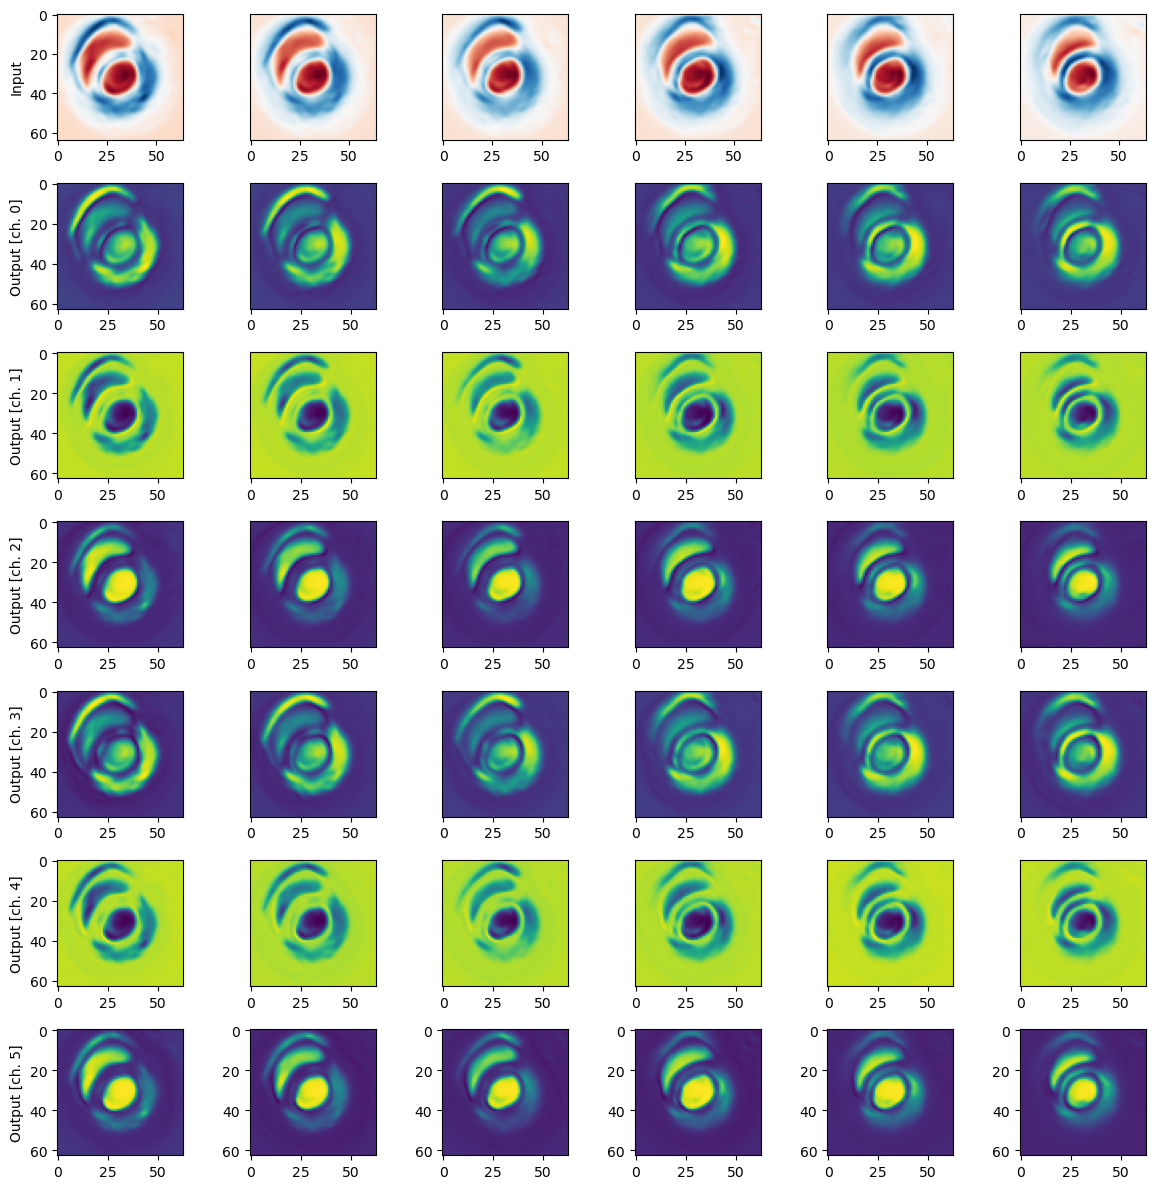

In [8]:
# PRINT SOME SAMPLES
n_samples = 6
n_channels = 6
fig, axes = plt.subplots(1 + n_channels, n_samples, figsize=(12, 12))
for k in range(n_samples):
    axes[0, 0].set_ylabel("Input")
    if k != 0:
        axes[0, k].yaxis.set_visible(False)
    axes[0, k].imshow(train_imgs_tf_rad[k, :, :, :])

    # Plot all output channels
    for c in range(n_channels):
        axes[c + 1, 0].set_ylabel("Output [ch. {}]".format(c))
        if k != 0:
            axes[c, k].yaxis.set_visible(False)
        axes[c + 1, k].imshow(q_train_images_rad[k, :, : ,c])

plt.tight_layout()
plt.show()

In [11]:
df_tr_rad[55:56]

,patient_name,class,image_type,img_number
119,MU_05,MU,radial,05


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


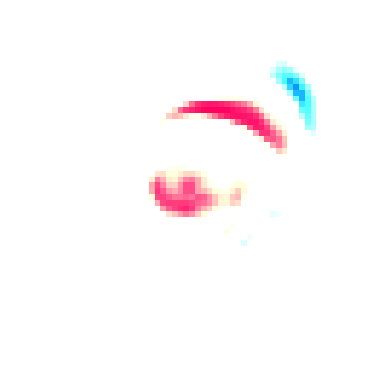

In [12]:
plt.imshow(train_imgs_tf_rad[55,:,:])
plt.axis('off')
plt.show()